In [23]:
!pip install -q qpsolvers[osqp]


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from qpsolvers import solve_qp

In [25]:
os.makedirs("data", exist_ok=True)

url = "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/ControlDeCalidad.txt"
ruta_archivo = "data/ControlDeCalidad.txt"

!wget -q -O {ruta_archivo} {url}

data = np.loadtxt(ruta_archivo, delimiter="\t")

X = data[:, :2]   # features
y = data[:, 2]    # etiquetas

print(X.shape)
print(y.shape)

print(data)

(16, 2)
(16,)
[[ 0.4 -0.7  0. ]
 [-1.5 -1.   0. ]
 [-1.4 -0.9  0. ]
 [-1.3 -1.2  0. ]
 [-1.1 -0.2  0. ]
 [-1.2 -0.4  0. ]
 [-0.5  1.2  0. ]
 [-1.5  2.1  0. ]
 [ 1.   1.   1. ]
 [ 1.3  0.8  1. ]
 [ 1.2  0.5  1. ]
 [ 0.2 -2.   1. ]
 [ 0.5 -2.4  1. ]
 [ 0.2 -2.3  1. ]
 [ 0.  -2.7  1. ]
 [ 1.3  2.1  1. ]]


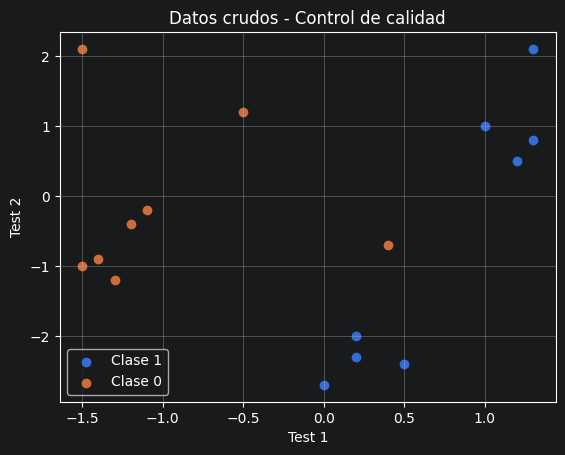

In [26]:
plt.figure()

# separar clases
pos = y == 1
neg = y == 0

plt.scatter(X[pos, 0], X[pos, 1], label="Clase 1")
plt.scatter(X[neg, 0], X[neg, 1], label="Clase 0")

plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.title("Datos crudos - Control de calidad")
plt.legend()
plt.grid()

plt.show()

**Problema primal de SVM*

Se busca dividir el espacio a traves de hiperplanos, maximizando el margen entre las muestras, esto se expresa en la siguiente ecuacion:

$$J_1 = \min_{w,b} \frac{1}{2} \lVert w \rVert ^2 \quad s.t. \quad y_i(w^T x_i + b) \geq 1 \quad \forall \quad 1 \leq i \leq n$$

Donde el margen entre las muestras viene dado por:

$$m(b,w) = \frac{1}{\lVert w \rVert}$$

Cuando los conjuntos no son linealmente separables se pueden proyectar las muestras a un espacio de mayor dimension, donde la ecuación del problema se convierte en la siguiente:

$$J_1 = \min_{w,b} \frac{1}{2} \lVert w \rVert ^2 \quad s.t. \quad y_i(w^T \phi(x_i) + b) \geq 1 \quad \forall \quad 1 \leq i \leq n$$

**Problema dual de SVM**

Para esto se reescibe el problema primal utilizando multiplicadores de lagrange

$$J_1 = \min_{w,b} \max_{\alpha_i \geq 0} \frac{1}{2} \lVert w \rVert ^2 - \sum_{i=1}^{n_{tr}} \alpha_i \left[ y_i(w^T \phi(x_i) + b) - 1 \right]$$

La igualdad con la primera ecuacion se puede analizar en los tres casos de la condicion para los pares $(w,b)$

- Si $y_i(w^T x_i + b) > 1$, $\alpha_i$ debe ser igual a cero para maximizar la expresión.
- Si $y_i(w^T x_i + b) = 1$, $\alpha_i$ se vuelve irrelevante, ya que está multiplicado por 0.
- Si $y_i(w^T x_i + b) < 1$, el $\max_{\alpha_i \geq 0}$ obliga a $\alpha_i$ a tender a $\infty$, pero eso resultaría en que $\min_{w,b}$ descarte el par $(w,b)$

De esta forma, el término de la sumatoria no altera el resultado de la primera forma de escribir a $J_1$

Además, los $\alpha_i$ se pueden utilizar para detectar los vectores soporte, los que corresponden a vectores que cumplen la igualdad van a ser los unicos (y mayores, por la restricción inicial) a cero.

Con la intención de simplificar el problema, se intercambian el minimo y el máximo, llegando finalmente al problema dual:

$$J_2 =  \max_{\alpha_i \geq 0} \min_{w,b} \frac{1}{2} \lVert w \rVert ^2 - \sum_{i=1}^{n_{tr}} \alpha_i \left[ y_i(w^T \phi(x_i) + b) - 1 \right]$$

Ahora el problema se basa en optimizar respecto a $(w,b)$. Primero se asumirá $\alpha_i$ constante, y utilizando las derivadas del lagraniano:

$$\mathcal{L}([w,b],[\alpha_1, ..., \alpha_i]) = \frac{1}{2} \lVert w \rVert ^2 - \sum_{i=1}^{n_{tr}} \alpha_i \left[ y_i(w^T \phi(x_i) + b) - 1 \right]$$

$$\frac{d\mathcal{L}([w,b],[\alpha_1, ..., \alpha_i])}{dw} = w - \sum^{n_tr}_{i=1} \alpha_i y_i \phi(x_i)$$

$$\frac{d\mathcal{L}([w,b],[\alpha_1, ..., \alpha_i])}{db} =- \sum^{n_tr}_{i=1} \alpha_i y_i$$

Igualando las derivadas a cero, se deduce:

$$w^* = \sum^{n_tr}_{i=1} \alpha_i y_i \phi(x_i)$$

Y luego $b^*$ impone $\alpha^T y = 0$

Luego, reemplazando estos valores en el lagraniano y operando matemáticamente para llegar a un producto matricial se obtiene:

 $$\mathcal{L}([w,b],[\alpha_1, ..., \alpha_i]) = \alpha^T \mathcal{1} - \frac{1}{2} \alpha^T Q \alpha$$

Por ultimo, se llega a la expresión de $J_2$ que se va a utilizar para resolver el problema de SVM:

$$ J_2 = \max_{\alpha} \alpha^T \mathcal{1} - \frac{1}{2} \alpha^T Q \alpha \quad s.t. \quad \alpha^T y = 0 , \alpha_i \geq 0 \quad \forall \quad 1, ... , n$$

Y los valores b se obtienen de la siguiente forma:

$$b ^ * = \frac{1}{N_s} \sum_{i \in \mathbf{S}} \left( y_i - \sum_{j \in \mathbf{S}} \alpha_i y_i k(x_i, x_j) \right)$$

Donde $\mathbf{S}$ es el conjunto de los vectores soporte y $N_s$ es la cantidad de vectores soporte.

**Resolucion con solve_qp**

Según documentación, solve_qp resuelve el siguiente problema:

$$\min_{x} \frac{1}{2} x^T P x + q^T x \quad s.t. \quad Gx \leq h , Ax = b$$

Para adaptarse al solver, se buscará

$$ J_2 = \min_{\alpha} \frac{1}{2} \alpha^T Q \alpha - \alpha^T \mathcal{1} \quad s.t. \quad \alpha^T y = 0 , \alpha_i \geq 0 \quad \forall \quad 1, ... , n$$

Luego resulta evidente $\alpha = x$, entonces $P = Q$ , $q = - [1,1, ..., 1]$

$$Gx \leq h \Rightarrow - \alpha_i \leq 0$$

$$G = - \mathbf{I} \quad \quad h = \mathbf{0}$$

Por ultimo, $Ax = b \Rightarrow \alpha^T y = 0$




In [27]:
class SVM:
    # Inicializar atributos y declarar hiperpar´ametros.
    def __init__(self, kernel, gamma=1.0):
        self.kernel = kernel
        self.gamma = gamma

        self.alpha = None
        self.support_vectors = None
        self.support_labels = None
        self.b = None

    # Etapa de entrenamiento.
    def fit(self, X, y):
        n = X.shape[0]

        # pasar etiquetas a {-1, +1}
        y = 2*y - 1
        y = y.astype(float)

        # matriz de Gram
        K = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                K[i, j] = self.kernel(X[i], X[j], self.gamma)

        # matrices del QP (hard margin)
        P = np.outer(y, y) * K
        q = -np.ones(n)

        # SOLO restricción α >= 0
        G = -np.eye(n)
        h = np.zeros(n)

        A = y.reshape(1, -1)
        b = np.array([0.0])

        # resolver QP
        alpha = solve_qp(P, q, G, h, A, b, solver="osqp")

        # vectores soporte
        sv = alpha > .1

        self.alpha = alpha[sv]
        self.support_vectors = X[sv]
        self.support_labels = y[sv]

        # calcular b
        b_vals = []
        for i in range(len(self.alpha)):
            s = 0
            for j in range(len(self.alpha)):
                s += self.alpha[j] * self.support_labels[j] * \
                     self.kernel(self.support_vectors[j], self.support_vectors[i], self.gamma)
            b_vals.append(self.support_labels[i] - s)

        self.b = np.mean(b_vals)

    # Etapa de testeo hard
    def predict(self, X):
        return np.sign(self.predict_soft(X))

    # Etapa de testeo soft
    def predict_soft(self, X):
        y_pred = []

        for x in X:
            s = 0
            for alpha_i, y_i, sv in zip(self.alpha, self.support_labels, self.support_vectors):
                s += alpha_i * y_i * self.kernel(sv, x, self.gamma)
            y_pred.append(s + self.b)

        return np.array(y_pred)

In [28]:
def linear_kernel(x1, x2, gamma=None):
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)
    return np.dot(x1, x2)

In [29]:
svm = SVM(kernel=linear_kernel, gamma=1.0)
svm.fit(X, y)

In [30]:
y_train = 2*y - 1  # si tu y original era 0/1

y_pred = svm.predict(X)

accuracy = np.mean(y_pred == y_train)

print("Accuracy entrenamiento:", accuracy)

Accuracy entrenamiento: 1.0


**Margen unilateral**

Para el caso del kernel lineal se puede reconstruir el $w$ como:

$$w = \sum_i \alpha_i y_i x_i$$

Utilizando los $x_i, y_i$ de los vectores soporte.

In [31]:
# reconstruir w
w = np.zeros(X.shape[1])

for alpha_i, y_i, sv in zip(svm.alpha, svm.support_labels, svm.support_vectors):
    w += alpha_i * y_i * sv

# norma
norm_w = np.linalg.norm(w)

# margen unilateral (lo que pedís)
margin_unilateral = 1 / norm_w

print("Norma ||w||:", norm_w)
print("Margen unilateral:", margin_unilateral)

Norma ||w||: 14.763384946898872
Margen unilateral: 0.06773514364062257


In [32]:
def plot_svm_decision_boundary(svm, X, y, resolution=200):

    # pasar etiquetas a {-1, +1}
    y_plot = 2*y - 1

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # función de decisión
    Z = svm.predict_soft(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))

    # región de decisión
    plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.3)

    # frontera y márgenes
    plt.contour(xx, yy, Z, levels=[-1, 0, 1],
                colors=["blue", "black", "blue"],
                linestyles=["--", "-", "--"],
                linewidths=1.5)

    # scatter datos
    pos = y_plot == 1
    neg = y_plot == -1

    plt.scatter(X[pos, 0], X[pos, 1], label="Clase +1")
    plt.scatter(X[neg, 0], X[neg, 1], label="Clase -1")

    # vectores soporte
    plt.scatter(
        svm.support_vectors[:, 0],
        svm.support_vectors[:, 1],
        s=120,
        facecolors="none",
        edgecolors="k",
        linewidths=2,
        label="Vectores soporte"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Frontera de decisión SVM")
    plt.legend()
    plt.grid()
    plt.show()

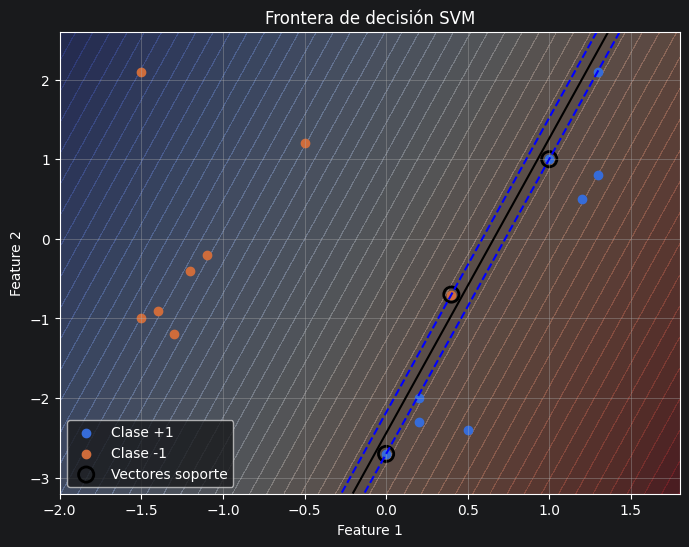

In [33]:
plot_svm_decision_boundary(svm, X, y)

Se puede ver como la frontera separa el plano dejando de un lado los productos que pasaron el control de calidad y del otro los que no. Resulta destacable el bajo margen que se obtuvo, el cual se puede apreciar facilmente en el gráfico y también por el valor obtenido.

In [34]:
def poly_cubed_kernel(x1, x2, gamma):
    return (gamma * np.dot(x1, x2)) ** 3

In [35]:
svm_poly = SVM(kernel=poly_cubed_kernel, gamma=0.3)
svm_poly.fit(X, y)

In [36]:
y_true = 2*y - 1
y_pred = svm_poly.predict(X)

accuracy = np.mean(y_pred == y_true)

print("Accuracy entrenamiento:", accuracy)

Accuracy entrenamiento: 1.0


**Margen con kernel no lineal:**

Para el kernel no lineal se puede obtener directamente $\lVert w \rVert ^ 2$ de la siguiente forma:

$$\lVert w \rVert ^ 2 = \sum_{i,j} \alpha_i \alpha_j y_i y_j K(x_i, x_j)$$

Utilizando los vectores soporte.

In [37]:
# reconstrucción de ||w||^2 en el espacio de features
norm_w2_poly = 0

for i in range(len(svm_poly.alpha)):
    for j in range(len(svm_poly.alpha)):
        norm_w2_poly += (
            svm_poly.alpha[i] * svm_poly.alpha[j] *
            svm_poly.support_labels[i] * svm_poly.support_labels[j] *
            svm_poly.kernel(svm_poly.support_vectors[i], svm_poly.support_vectors[j], svm_poly.gamma)
        )

norm_w_poly = np.sqrt(norm_w2_poly)

margin_unilateral_poly = 1 / norm_w_poly

print("||w||:", norm_w_poly)
print("Margen unilateral:", margin_unilateral_poly)

||w||: 6.117300128778565
Margen unilateral: 0.16347080884515452


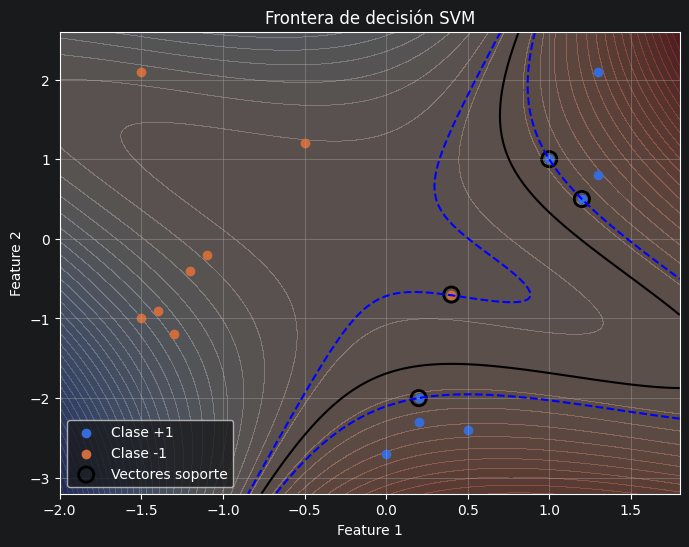

In [38]:
plot_svm_decision_boundary(svm_poly, X, y)

En este caso, como el kernel ya no es lineal, se puede ver como la frontera (curva de nivel 0 de la función de decision) y los márgenes (curvas de nivel 1 y -1 de la función de decisión) ya no son lineas rectas, al haber proyectado los datos sobre un espacio de mayor dimensión que el plano, la representación de las curvas de nivel no tiene por que ser lineal. Se puede apreciar tanto en el gráfico como en el valor obtenido que el margen unilateral es considerablemente mejor que en el caso del kernel lineal.

In [39]:
def rbf_kernel(x1, x2, gamma):
    diff = x1 - x2
    return np.exp(-gamma * np.dot(diff, diff))

In [40]:
svm_rbf = SVM(kernel=rbf_kernel, gamma=1)
svm_rbf.fit(X, y)

In [41]:
y_true = 2*y - 1
y_pred = svm_rbf.predict(X)

accuracy = np.mean(y_pred == y_true)

print("Accuracy entrenamiento:", accuracy)

Accuracy entrenamiento: 1.0


In [42]:
# reconstrucción de ||w||^2 en el espacio de features
norm_w2_rbf = 0

for i in range(len(svm_rbf.alpha)):
    for j in range(len(svm_rbf.alpha)):
        norm_w2_rbf += (
            svm_rbf.alpha[i] * svm_rbf.alpha[j] *
            svm_rbf.support_labels[i] * svm_rbf.support_labels[j] *
            svm_rbf.kernel(svm_rbf.support_vectors[i], svm_rbf.support_vectors[j], svm_rbf.gamma)
        )

norm_w_rbf = np.sqrt(max(norm_w2_rbf, 0))

margin_unilateral_rbf = 1 / norm_w_rbf

print("||w||:", norm_w_rbf)
print("Margen unilateral:", margin_unilateral_rbf)

||w||: 2.7742039011903956
Margen unilateral: 0.3604637710915573


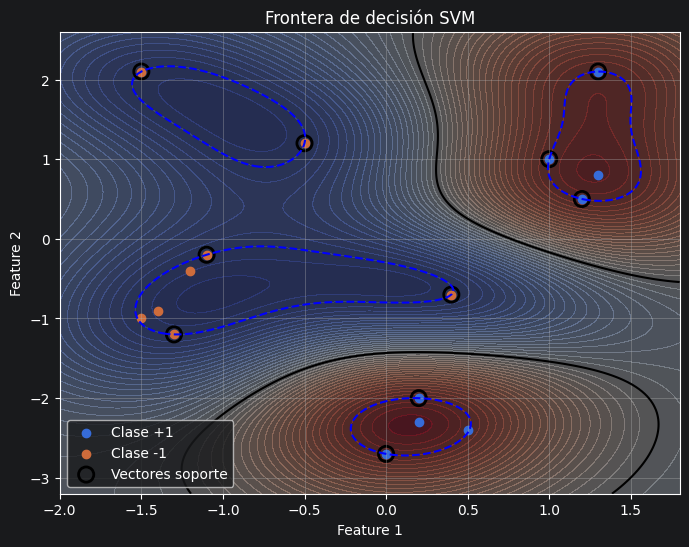

In [43]:
plot_svm_decision_boundary(svm_rbf, X, y)

En este ultimo caso, se proyectan los datos sobre un espacio de dimensión infinita, por lo que resulta esperable que las curvas de nivel estén lejos de ser lineales. Se puede ver como los margenes encierran de forma mucho más compacta a los vectores, resultando mucho más clara la division entre los que pasaron el control de calidad y los que no. Por ultimo, el margen resulta considerablemente más grande que en los casos anteriores, nuevamente se atribuye a la forma en la que la frontera divide al plano al proyectarse en este.